# MEDA Multi-Model Training and Evaluation

In [7]:
from pathlib import Path
import sys, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
OUTPUTS, MODELS = ROOT/'outputs', ROOT/'models'
sns.set_theme(style='whitegrid')

comparison=pd.read_csv(OUTPUTS/'model_comparison_v2.csv'); display(comparison.sort_values(['split','mse']))

,model,split,train_rows,valid_rows,mse,rmse,mae,r2,fit_seconds,inference_seconds
7,physics_residual,final_test,209092,39000,4.774073,2.184965,1.656699,0.755195,16.854452,0.359830
6,physics_residual,validation,170092,39000,4.890104,2.211358,1.814396,0.816252,19.357641,0.336665
1,harmonic_ridge,validation,170092,39000,6.926848,2.631891,2.147760,0.739720,4.723605,0.305036
4,catboost,validation,170092,39000,8.121050,2.849746,2.286502,0.694847,43.874797,0.135217
2,random_forest,validation,120000,39000,8.435310,2.904361,2.330763,0.683039,105.575931,1.516007
3,xgboost,validation,170092,39000,8.441610,2.905445,2.343513,0.682802,19.400613,0.372051
0,median_baseline,validation,170092,39000,112.407921,10.602260,9.325596,-3.223785,0.175172,0.014509
5,mlp,validation,120000,39000,300.867859,17.345543,12.398902,-10.305264,77.057070,0.208962


## Comparative outcome

Seven candidates were compared: a median baseline, harmonic Ridge, Random Forest, XGBoost, CatBoost, MLP and a physics-residual hybrid. Selection used validation MSE only; the best validation candidate was **physics_residual (MSE 4.890, RMSE 2.211 Pa)**. The final exported model is **physics_residual**. Fit and inference timings are reported because an operational virtual sensor must be accurate and responsive. Unequal bounded training sizes for Random Forest and MLP remain a hardware-driven limitation, so their ranking is not a pure algorithm-only comparison.

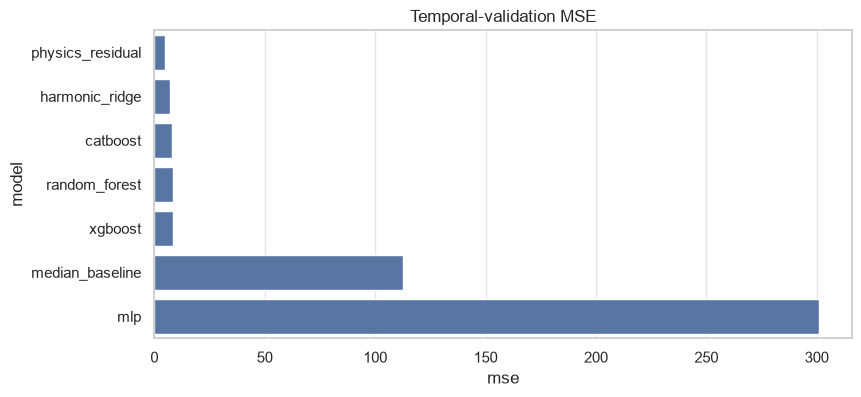

In [8]:
v=comparison[comparison.split=='validation'].sort_values('mse'); plt.figure(figsize=(9,4)); sns.barplot(v,x='mse',y='model'); plt.title('Temporal-validation MSE'); plt.show()

## Figure 1 - Model comparison

**Finding.** The selected validation model achieved MSE **4.890**, while nonlinear and harmonic alternatives showed materially different temporal behaviour.

**Implication.** Model selection uses temporal error rather than random-split accuracy or leaderboard position.

**Limitation.** Training row caps and one competition dataset limit broad algorithmic conclusions.

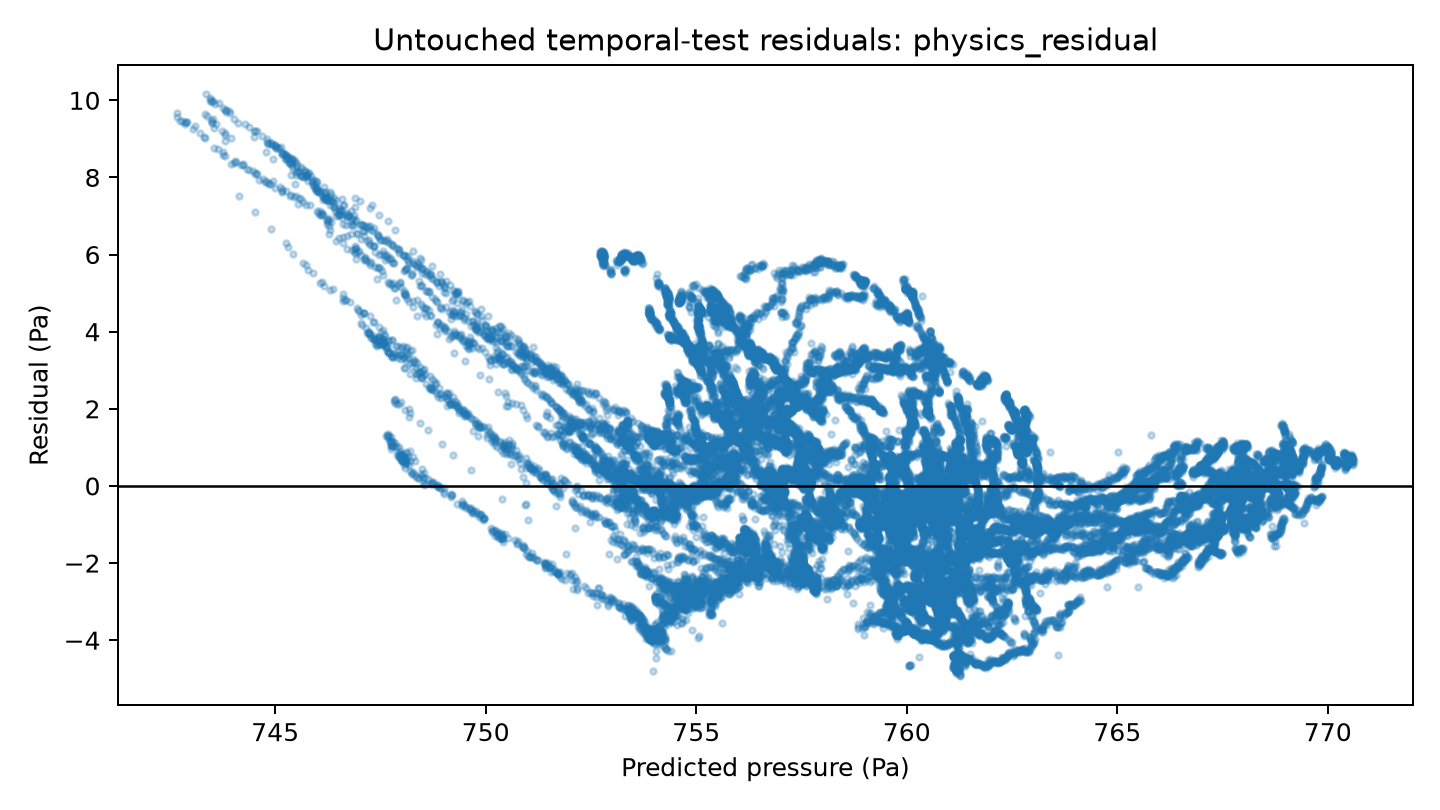

In [9]:
from IPython.display import Image, display
display(Image(filename=str(OUTPUTS/'figures/evaluation_residuals.png')))

## Figure 2 - Residuals

**Finding.** On sols 87-100, the selected model produced RMSE **2.185 Pa**, MAE **1.657 Pa**, and R² **0.755**.

**Implication.** Residual structure is treated as evidence about regime misspecification, not only as a score.

**Limitation.** This test does not reach the Kaggle test sols; public-score disagreement must remain explicit.

## Hardware constraint

The recorded system has six logical CPUs and 7.69 GB RAM. Tree and neural models therefore use three CPU threads, float32 data and bounded samples. These constraints favour a compact deployment artifact and make an exhaustive search inappropriate; trial histories and seeds preserve reproducibility.